# Предсказание волатильности по новостям с сайта Forex Factory

## Загрузка новостей

In [1]:
import pandas as pd
import numpy as np
import pytz
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from warnings import filterwarnings
filterwarnings('ignore')

from tqdm.auto import tqdm
tqdm.pandas()

from typing import Literal

In [2]:
moscow_tz = pytz.timezone('Europe/Moscow')
news_tz = pytz.timezone('Asia/Tehran')

In [3]:
PATH_TO_NEWS = "C:/Users/user/Documents/projects/ALGO/algotrading/dataset/economy_calendar/forex_factory_cache.csv"
news = pd.read_csv(PATH_TO_NEWS)
news.head()

,DateTime,Currency,Impact,Event,Actual,Forecast,Previous,Detail
0,2007-01-01T04:30:00+03:30,CNY,High Impact Expected,Manufacturing PMI,54.8,NaN,55.3,Source: CFLP (latest release) | Measures: Leve...
1,2007-01-01T23:59:59+03:30,CAD,Non-Economic,Bank Holiday,NaN,NaN,NaN,Description: Canadian banks will be closed in ...
2,2007-01-01T23:59:59+03:30,USD,Non-Economic,Bank Holiday,NaN,NaN,NaN,Description: US banks will be closed in observ...
3,2007-01-01T23:59:59+03:30,CNY,Non-Economic,Bank Holiday,NaN,NaN,NaN,Description: Chinese banks will be closed in o...
4,2007-01-01T23:59:59+03:30,EUR,Non-Economic,German Bank Holiday,NaN,NaN,NaN,FF Notice: The European Central Bank's Trans-E...


In [4]:
news.shape

(83427, 8)

In [6]:
pd.to_datetime(news['DateTime']).max()

Timestamp('2025-04-07 22:30:00+0430', tz='UTC+04:30')

In [5]:
news['Impact'].value_counts()

Impact
Low Impact Expected       40005
Medium Impact Expected    23180
High Impact Expected      17842
Non-Economic               2400
Name: count, dtype: int64

In [6]:
news['Impact'].value_counts(normalize=True)

Impact
Low Impact Expected       0.479521
Medium Impact Expected    0.277848
High Impact Expected      0.213864
Non-Economic              0.028768
Name: proportion, dtype: float64

In [6]:
def set_rank_for_impact(impact: str):
    if impact == 'High Impact Expected':
        return 3
    elif impact == 'Medium Impact Expected':
        return 2
    elif impact == 'Low Impact Expected':
        return 1
    else:
        return 0

In [7]:
news['impact_rank'] = news['Impact'].apply(set_rank_for_impact)

In [8]:
news['impact_rank'].value_counts()

impact_rank
1    40005
2    23180
3    17842
0     2400
Name: count, dtype: int64

### Подсчет слов

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

In [10]:
def get_ngram_word_counts(df, column='Event', ngram_range=(1, 2), min_df=1, max_features=None):
    """
    Calculate word/phrase counts using sklearn CountVectorizer with ngram support
    
    Parameters:
    df: DataFrame containing the data
    column: column name with text data
    ngram_range: tuple of (min_n, max_n) for n-grams
    min_df: minimum document frequency
    max_features: maximum number of features to return
    
    Returns:
    DataFrame with 'word' and 'count' columns
    """
    
    # Get all text data
    text_data = df[column].dropna().astype(str)
    
    # Create CountVectorizer with ngram support
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        min_df=min_df,
        max_features=max_features,
        stop_words='english',  # Remove common English stop words
        lowercase=True
    )
    
    # Fit and transform the text data
    word_matrix = vectorizer.fit_transform(text_data)
    
    # Get feature names (words/phrases)
    feature_names = vectorizer.get_feature_names_out()
    
    # Calculate total count for each word/phrase
    word_counts = word_matrix.sum(axis=0).A1  # .A1 converts matrix to 1D array
    
    # Create DataFrame
    result_df = pd.DataFrame({
        'word': feature_names,
        'count': word_counts
    }).sort_values('count', ascending=False)
    
    return result_df

In [11]:
event_count = get_ngram_word_counts(news, column='Event')
event_count

,word,count
1059,pmi,7556
1267,speaks,7453
777,manufacturing,6055
622,index,5349
1202,sales,5081
...,...,...
520,gold asset,1
1363,unconditional basic,1
1362,unconditional,1
619,income vote,1


In [12]:
event_count_detail = get_ngram_word_counts(news, column='Detail')
event_count_detail

,word,count
30006,release,189889
33157,source,108869
30104,released,94926
10229,currency,92879
13118,effect,85355
...,...,...
16411,g20 reshaping,1
16413,g20 symposium,1
16417,g30 report,1
39902,zone policy,1


In [ ]:
# def classify_news(s: str):
#     s = str(s)
    
#     if 'PMI' in s:
#         return 'PMI'
#     elif 'CPI' in s:
#         return 'CPI'
#     elif 'FOMC' in s:
#         return 'FOMC'
#     elif 'PPI' in s:
#         return 'PPI'
#     elif 'farm' in s.lower():
#         return 'Non-farm'
#     elif 'Inflation' in s:
#         return 'Inflation'
#     elif 'Retail Sales' in s:
#         return 'Retail Sales'
#     # else:
#     #     return 'Other'
# df['Category'] = df['Event'].apply(classify_news)

### Классификация новостей по группам

In [13]:
NEWS_CLASSES = [
    "MONETARY_POLICY",      # решения ЦБ
    "CB_SPEECH",            # речи ЦБ
    "INFLATION",            # инфляция
    "LABOR_MARKET",         # рынок труда
    "ECONOMIC_ACTIVITY",    # рост / производство
    "SENTIMENT",            # опросы / ожидания
    "CONSUMER_HOUSING",     # потребитель / жильё
    "TRADE_FINANCE",        # торговля / деньги / финансы
    "COMMODITIES"           # нефть / газ / сырьё
]

In [14]:
MONETARY_POLICY = [
    "rate", "policy", "monetary", "fomc", "mpc", "meeting",
    "minutes", "statement", "votes",
    "asset purchase", "purchase facility", "refinancing",
    "cash rate", "bank rate", "official cash",
    "fed", "ecb", "boe", "boj", "rba", "rbnz", "boc", "snb",
    "overnight rate", "federal funds", "funds rate"
]

CB_SPEECH = [
    "speaks", "press conference", "press",
    "chair", "president", "gov",
    "powell", "lagarde", "bailey", "kuroda", "draghi",
    "yellen", "carney", "bullard", "waller", "kashkari",
    "member"
]

INFLATION = [
    "cpi", "core cpi", "ppi", "core ppi",
    "pce", "core pce",
    "inflation", "price index", "prices",
    "median cpi", "trimmed cpi",
    "inflation expectations"
]

LABOR_MARKET = [
    "employment", "unemployment", "job", "claims",
    "non farm", "nonfarm", "payrolls",
    "adp", "jolts", "job openings",
    "earnings", "hourly earnings",
    "job cuts", "challenger"
]

ECONOMIC_ACTIVITY = [
    "gdp", "industrial", "production",
    "manufacturing", "services",
    "orders", "factory orders",
    "output", "capacity", "utilization",
    "productivity", "investment"
]

SENTIMENT = [
    "pmi", "ism", "confidence", "sentiment",
    "ifo", "zew", "gfk", "nfib", "philly",
    "survey", "optimism", "barometer",
    "expectations", "watchers"
]

CONSUMER_HOUSING = [
    "retail", "sales", "consumer",
    "housing", "home", "mortgage",
    "building", "permits", "starts",
    "house price", "hpi"
]

TRADE_FINANCE = [
    "trade", "balance", "current account",
    "budget", "borrowing", "credit",
    "money supply", "m2", "m3",
    "lending", "loans", "reserves",
    "foreign", "currency"
]

COMMODITIES = [
    "oil", "crude", "gas",
    "inventories", "storage",
    "opec", "commodity prices"
]

In [15]:
CLASS_KEYWORDS = {
    "MONETARY_POLICY": MONETARY_POLICY,
    "CB_SPEECH": CB_SPEECH,
    "INFLATION": INFLATION,
    "LABOR_MARKET": LABOR_MARKET,
    "ECONOMIC_ACTIVITY": ECONOMIC_ACTIVITY,
    "SENTIMENT": SENTIMENT,
    "CONSUMER_HOUSING": CONSUMER_HOUSING,
    "TRADE_FINANCE": TRADE_FINANCE,
    "COMMODITIES": COMMODITIES
}


In [16]:
def classify_news(title: str):
    title = title.lower()
    scores = {}

    for cls, keywords in CLASS_KEYWORDS.items():
        scores[cls] = sum(1 for k in keywords if k in title)

    if max(scores.values()) == 0:
        return "OTHER"

    return max(scores, key=scores.get)

In [17]:
news['class'] = news['Event'].astype(str).apply(classify_news)

In [18]:
news['class'].value_counts()

class
ECONOMIC_ACTIVITY    15110
INFLATION            11199
OTHER                10601
CONSUMER_HOUSING      9495
CB_SPEECH             8344
TRADE_FINANCE         7311
MONETARY_POLICY       6929
LABOR_MARKET          6223
SENTIMENT             5768
COMMODITIES           2447
Name: count, dtype: int64

## Загрузка котировок

In [19]:
import MetaTrader5 as mt5
from datetime import datetime

In [20]:
def get_prices_from_mt5(ticker: str, tf=mt5.TIMEFRAME_D1, from_date: datetime = datetime(2010, 1, 1), till_date: datetime = datetime.now()):
    # connect to MetaTrader 5
    path_to_terminal = "C:\\Program Files\\AMarkets - MetaTrader 5\\terminal64.exe"
    if not mt5.initialize(path=path_to_terminal):
        print("initialize() failed")
        mt5.shutdown()

    rates = mt5.copy_rates_range(ticker, tf, from_date, till_date)
    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df = df.drop(['real_volume'], axis=1)
    for col in ['open', 'high', 'low', 'close']:
        df[col] = df[col].apply(lambda x: np.round(x, 5))
    return df

In [21]:
prices = get_prices_from_mt5('EURUSDb', mt5.TIMEFRAME_H1, from_date=datetime(2014, 1, 1), till_date=datetime(2025, 4, 10))

In [22]:
prices.head()

,time,open,high,low,close,tick_volume,spread
0,2014-01-01 23:00:00,1.37550,1.37648,1.37372,1.37580,3174,0
1,2014-01-02 00:00:00,1.37581,1.37730,1.37578,1.37645,2347,0
2,2014-01-02 01:00:00,1.37645,1.37684,1.37581,1.37586,1052,0
3,2014-01-02 02:00:00,1.37585,1.37662,1.37504,1.37626,1184,0
4,2014-01-02 03:00:00,1.37624,1.37676,1.37596,1.37660,858,0


In [23]:
print('News min date: ', pd.to_datetime(news['DateTime']).min())
print('News max date: ', pd.to_datetime(news['DateTime']).max())

News min date:  2007-01-01 04:30:00+03:30
News max date:  2025-04-07 22:30:00+04:30


In [24]:
print(prices['time'].describe())

count                            69710
mean     2019-08-21 22:46:33.498780416
min                2014-01-01 23:00:00
25%                2016-10-26 21:15:00
50%                2019-08-20 09:30:00
75%                2022-06-16 10:45:00
max                2025-04-09 21:00:00
Name: time, dtype: object


# Присоеднить новости к ценам

In [25]:
prices['utc_dt'] = pd.to_datetime(prices['time']).dt.tz_localize(moscow_tz)
news['utc_dt'] = pd.to_datetime(news['DateTime'], utc=True).dt.tz_convert(moscow_tz)

> Round hours

In [26]:
# Method 1: Using floor to get the hour closest to start of hour
# news['utc_dt_rounded'] = news['utc_dt'].dt.floor('H')
news['utc_dt_rounded'] = news['utc_dt'].dt.ceil('H', ambiguous='NaT', nonexistent='shift_forward')

> Это для подсчета статистики (оставляем самую импактовую новость)

In [31]:
news_agg = news.loc[news.groupby('utc_dt_rounded')['impact_rank'].idxmax()]

In [32]:
news_agg.head()

,DateTime,Currency,Impact,Event,Actual,Forecast,Previous,Detail,impact_rank,class,utc_dt,utc_dt_rounded
0,2007-01-01T04:30:00+03:30,CNY,High Impact Expected,Manufacturing PMI,54.8,NaN,55.3,Source: CFLP (latest release) | Measures: Leve...,3,ECONOMIC_ACTIVITY,2007-01-01 04:00:00+03:00,2007-01-01 04:00:00+03:00
1,2007-01-01T23:59:59+03:30,CAD,Non-Economic,Bank Holiday,NaN,NaN,NaN,Description: Canadian banks will be closed in ...,0,OTHER,2007-01-01 23:29:59+03:00,2007-01-02 00:00:00+03:00
12,2007-01-02T02:00:00+03:30,AUD,Low Impact Expected,AIG Manufacturing Index,52.4,NaN,54.4,Source: Australian Industry Group (latest rele...,1,ECONOMIC_ACTIVITY,2007-01-02 01:30:00+03:00,2007-01-02 02:00:00+03:00
13,2007-01-02T03:30:00+03:30,CNY,Non-Economic,Bank Holiday,NaN,NaN,NaN,Description: Chinese banks will be closed in o...,0,OTHER,2007-01-02 03:00:00+03:00,2007-01-02 03:00:00+03:00
14,2007-01-02T06:00:00+03:30,CNY,Medium Impact Expected,Caixin Manufacturing PMI,52.4,NaN,53.0,Source: S&P Global (latest release) | Measures...,2,ECONOMIC_ACTIVITY,2007-01-02 05:30:00+03:00,2007-01-02 06:00:00+03:00


In [33]:
news_agg = news_agg[news_agg['Currency'].isin(['USD', 'EUR', 'GBP', 'CHF'])]

> Это на машинное обучение

In [114]:
def get_news_for_hour(news_at_hour: pd.DataFrame):
    return news_at_hour[['Event', 'class', 'Impact', 'impact_rank', 'Currency', 'Previous', 'Forecast', 'Actual']].to_dict('records')  # list ok

In [96]:
news_agg = news.groupby('utc_dt_rounded').progress_apply(get_news_for_hour).reset_index()
news_agg.columns = ['utc_dt_rounded', 'News at hour']

100%|██████████| 46882/46882 [00:33<00:00, 1416.53it/s]


In [79]:
news_agg

,utc_dt_rounded,News at hour
0,2007-01-01 04:00:00+03:00,"[{'Event': 'Manufacturing PMI', 'class': 'ECON..."
1,2007-01-02 00:00:00+03:00,"[{'Event': 'Bank Holiday', 'class': 'OTHER', '..."
2,2007-01-02 02:00:00+03:00,"[{'Event': 'AIG Manufacturing Index', 'class':..."
3,2007-01-02 03:00:00+03:00,"[{'Event': 'Bank Holiday', 'class': 'OTHER', '..."
4,2007-01-02 06:00:00+03:00,"[{'Event': 'Caixin Manufacturing PMI', 'class'..."
...,...,...
46877,2025-04-07 08:00:00+03:00,"[{'Event': 'German Industrial Production m/m',..."
46878,2025-04-07 09:00:00+03:00,"[{'Event': 'Foreign Currency Reserves', 'class..."
46879,2025-04-07 11:00:00+03:00,"[{'Event': 'Sentix Investor Confidence', 'clas..."
46880,2025-04-07 17:00:00+03:00,"[{'Event': 'BOC Business Outlook Survey', 'cla..."


## Merge with prices

In [34]:
# df = prices.merge(news, how='left', left_on='utc_dt', right_on='utc_dt_rounded')
df = prices.merge(news_agg, how='left', left_on='utc_dt', right_on='utc_dt_rounded')

# Featuring

In [35]:
import talib as ta
from hurst import compute_Hc
from tqdm.auto import tqdm

tqdm.pandas(desc="Processing DataFrame")

In [36]:
PERIOD = 12

In [37]:
# Ranges
# df['range'] = df['high'] - df['low']
df['range'] = ta.TRANGE(df['high'], df['low'], df['close'])
df['atr'] = ta.ATR(df['high'], df['low'], df['close'], PERIOD)
df['std'] = ta.STDDEV(df['close'], timeperiod=PERIOD)
df['std_mean'] = df['std'].rolling(window=PERIOD).mean()
df['std_cls'] = np.where(df['std'] > df['std_mean'], 1, 0)
df['adx'] = ta.ADX(df['high'], df['low'], df['close'], PERIOD)

# Volumes
df['volume_diff'] = df['tick_volume'].pct_change()

# Booleans
df['is_high_range'] = df.apply(lambda x: 1 if x['range'] > x['atr'] else 0, axis=1)
df['is_true_forecast'] = df['Actual'] == df['Forecast']

# Other
df['readable_range'] = df['range'] / 0.00001

## Индикаторы

### Volume and range

In [38]:
def add_rolling_volume_and_range(data: pd.DataFrame, window=3):
    data[f'{window}bar_volume_before'] = data['tick_volume'].rolling(window=window).sum().shift(1)
    data[f'{window}bar_volume_after'] = data[f'{window}bar_volume_before'].shift(-window-1)
    data[f'{window}bar_volume_ratio'] = data[f'{window}bar_volume_before'] / data[f'{window}bar_volume_after']
    data[f'{window}bar_range_before'] = (data['high'].rolling(window=3).max() - data['low'].rolling(window=3).min()).shift(1)
    data[f'{window}bar_range_after'] = data[f'{window}bar_range_before'].shift(-window-1)
    data[f'{window}bar_range_ratio'] = data[f'{window}bar_range_before'] / data[f'{window}bar_range_after']
    return data

In [39]:
windows = [1, 3, 6, 12, 24]
for window in windows:
    df = add_rolling_volume_and_range(df, window)

### Range efficiency
> Range efficiency показывает отношение ренджа (разницы между максимальной и минимальной ценой за N баров) к сумме всех ренждей за N баров. Оно показывает, сколько движений было в самом ренждже. Если значение близко к 1, значит сумма ренджей совпадает с тотальным ренджом. Если 0.5, значит много движений было внутри этих N баров.

In [48]:
def range_efficiency(data: pd.DataFrame, window: int = 3) -> float:
    """
    Calculates the range efficiency for a given window size on OHLC price data.
    
    Range efficiency is defined as the ratio of the total range (difference between
    highest high and lowest low over the window) to the sum of the ranges (high-low per bar)
    within that window. 
    Higher values indicate more directional movement within the window,
    while lower values indicate more choppy or noisy price action.
    """
    total_range = data.high.rolling(window).max() - data.low.rolling(window).min()
    sum_range = data.range.rolling(window=window).sum()
    return total_range / sum_range

In [41]:
df['range_efficiency'] = range_efficiency(df, PERIOD)

In [42]:
def add_rolling_range_efficiency(data: pd.DataFrame, window=3):
    data[f'{window}bar_range_efficiency_before'] = range_efficiency(data, window).shift(1)
    data[f'{window}bar_range_efficiency_after'] = data[f'{window}bar_range_efficiency_before'].shift(-window-1)
    data[f'{window}bar_range_efficiency_ratio'] = data[f'{window}bar_range_efficiency_before'] / data[f'{window}bar_range_efficiency_after']
    return data

In [43]:
windows = [3, 6, 12, 24]
for window in windows:
    df = add_rolling_range_efficiency(df, window)

In [44]:
df['range_efficiency'].describe()[['min', 'mean', 'max']]

min     0.133386
mean    0.307259
max     0.724299
Name: range_efficiency, dtype: float64

<Axes: >

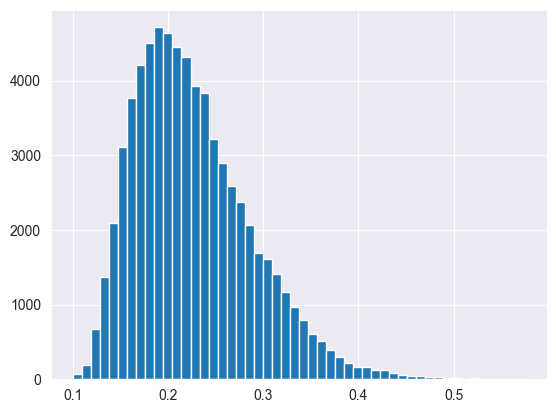

In [45]:
df['24bar_range_efficiency_after'].hist(bins=50)

In [46]:
df.groupby('Impact').agg({'6bar_range_efficiency_before': 'mean',
                          '6bar_range_efficiency_after': 'mean'})

,6bar_range_efficiency_before,6bar_range_efficiency_after
Impact,,
High Impact Expected,0.434272,0.422303
Low Impact Expected,0.423877,0.418407
Medium Impact Expected,0.425379,0.416549
Non-Economic,0.404365,0.367240


In [47]:
df.groupby('class').agg({'6bar_range_efficiency_before': 'mean',
                          '6bar_range_efficiency_after': 'mean'})

,6bar_range_efficiency_before,6bar_range_efficiency_after
class,,
CB_SPEECH,0.423593,0.412574
COMMODITIES,0.425619,0.423623
CONSUMER_HOUSING,0.422006,0.419836
ECONOMIC_ACTIVITY,0.430649,0.420128
INFLATION,0.427426,0.421752
LABOR_MARKET,0.423674,0.424105
MONETARY_POLICY,0.435067,0.423900
OTHER,0.427479,0.415894
SENTIMENT,0.427479,0.415213


### Directional noise index
> DNI is a measure, which measures the degree of directional noise in a market. It's calculated by dividing the absolute difference between the closing price and the opening price by the range

In [ ]:
def directional_noise_index(data: pd.DataFrame, window: int = 1) -> float:
    """
    Calculates the directional noise index (DNI) over a rolling window.
    DNI quantifies the proportion of directional movement (net move) relative to the total price movement (range) in the window.
    A higher value indicates price action is more directional/less noisy.
    Arguments:
      data: pd.DataFrame with 'open', 'close', and 'range' columns.
      window: int, rolling window size.
    Returns:
      pd.Series containing the directional noise index over the specified window.
    """
    net_move = (abs(data['close'] - data['open'])).rolling(window).sum()
    total_move = (data.range).rolling(window).sum()

    return net_move / total_move

In [50]:
df['dni'] = directional_noise_index(df, window=PERIOD)

<Axes: >

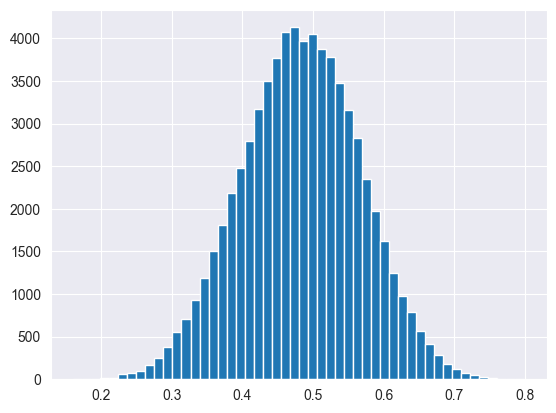

In [51]:
df['dni'].hist(bins=50)

In [52]:
def add_rolling_directional_noise_index(data: pd.DataFrame, window=3):
    data[f'{window}bar_directional_noise_index_before'] = directional_noise_index(data, window).shift(1)
    data[f'{window}bar_directional_noise_index_after'] = data[f'{window}bar_directional_noise_index_before'].shift(-window-1)
    data[f'{window}bar_directional_noise_index_ratio'] = data[f'{window}bar_directional_noise_index_before'] / data[f'{window}bar_directional_noise_index_after']
    return data

In [53]:
windows = [1, 3, 6, 12, 24]
for window in windows:
    df = add_rolling_directional_noise_index(df, window)

In [54]:
df.groupby('Impact').agg({'6bar_directional_noise_index_before': 'mean',
                          '6bar_directional_noise_index_after': 'mean'})

,6bar_directional_noise_index_before,6bar_directional_noise_index_after
Impact,,
High Impact Expected,0.485422,0.476046
Low Impact Expected,0.483078,0.479671
Medium Impact Expected,0.482908,0.476382
Non-Economic,0.450059,0.451101


In [55]:
df.groupby('class')[['3bar_directional_noise_index_before', '3bar_directional_noise_index_after', '3bar_directional_noise_index_ratio']].agg('mean')

,3bar_directional_noise_index_before,3bar_directional_noise_index_after,3bar_directional_noise_index_ratio
class,,,
CB_SPEECH,0.477238,0.464009,1.240997
COMMODITIES,0.472821,0.486333,1.125225
CONSUMER_HOUSING,0.481869,0.468751,1.229170
ECONOMIC_ACTIVITY,0.481790,0.476390,1.188178
INFLATION,0.479399,0.470077,1.192605
LABOR_MARKET,0.467863,0.465355,1.201296
MONETARY_POLICY,0.483733,0.461704,1.263269
OTHER,0.476165,0.473292,1.195739
SENTIMENT,0.475441,0.473855,1.189806


In [84]:
df.groupby('class')[['24bar_directional_noise_index_before', '24bar_directional_noise_index_after', '24bar_directional_noise_index_ratio']].agg('mean')

,24bar_directional_noise_index_before,24bar_directional_noise_index_after,24bar_directional_noise_index_ratio
class,,,
CB_SPEECH,0.488058,0.486025,1.020273
COMMODITIES,0.484841,0.486375,1.015078
CONSUMER_HOUSING,0.485932,0.484907,1.020156
ECONOMIC_ACTIVITY,0.485736,0.483320,1.020788
INFLATION,0.488964,0.487890,1.020035
LABOR_MARKET,0.483403,0.482900,1.019317
MONETARY_POLICY,0.487204,0.485763,1.019808
OTHER,0.484824,0.487521,1.011442
SENTIMENT,0.485348,0.483192,1.022629


<Axes: xlabel='dni', ylabel='range_efficiency'>

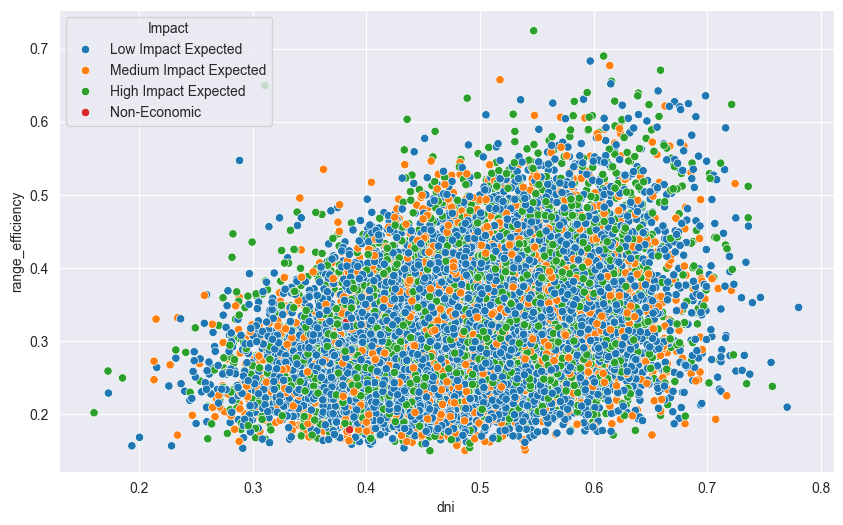

In [64]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='dni', y='range_efficiency', hue='Impact')

In [65]:
df[['range_efficiency', 'dni']].corr()

,range_efficiency,dni
range_efficiency,1.00000,0.30202
dni,0.30202,1.00000


### Hurst exponent

In [67]:
def rolling_hurst(series: pd.Series, window=100):
    def get_h(sub_series):
        if len(sub_series) < 50:
            return np.nan
        H, _, _ = compute_Hc(sub_series, kind='price', simplified=True)
        return H
    
    return series.rolling(window=window).progress_apply(get_h, raw=False)

In [68]:
df['hurst'] = rolling_hurst(df['close'], window=100)

Processing DataFrame: 69611it [00:40, 1709.04it/s]


In [69]:
def add_hurst_before_and_after(data: pd.DataFrame, window=3):
    data[f'{window}bar_hurst_before'] = data['hurst'].shift(1)
    data[f'{window}bar_hurst_after'] = data['hurst'].shift(-window)
    data[f'{window}bar_hurst_ratio'] = data[f'{window}bar_hurst_before'] / data[f'{window}bar_hurst_after']
    return data

In [70]:
windows = [1, 3, 6, 12, 24]
for window in windows:
    df = add_hurst_before_and_after(df, window)

<Axes: xlabel='24bar_directional_noise_index_before', ylabel='24bar_directional_noise_index_after'>

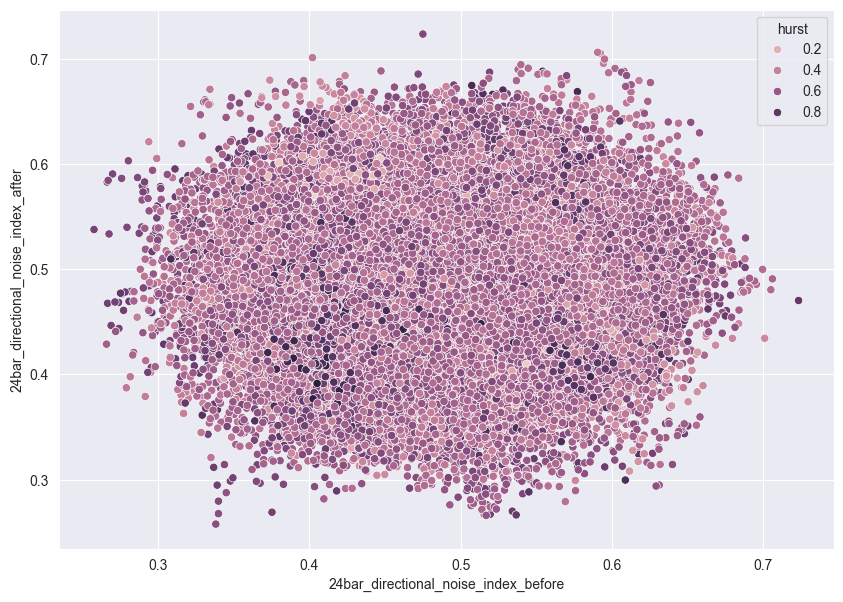

In [86]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='24bar_directional_noise_index_before', y='24bar_directional_noise_index_after', hue='hurst')

<Axes: xlabel='range_efficiency', ylabel='dni'>

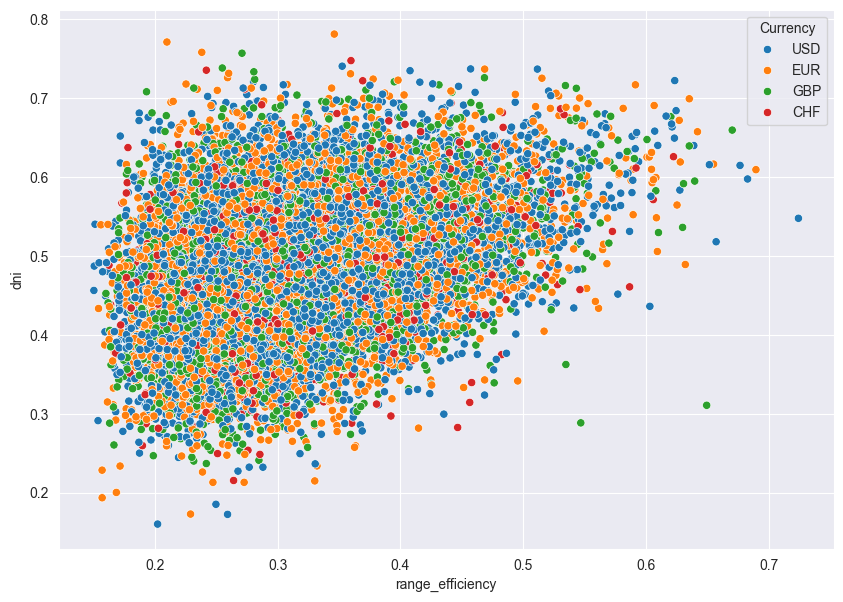

In [80]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='range_efficiency', y='dni', hue='Currency')

# Статистика

In [72]:
from scipy import stats
import pingouin as pg

In [73]:
df.columns

Index(['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread',
       'utc_dt_x', 'DateTime', 'Currency',
       ...
       '3bar_hurst_ratio', '6bar_hurst_before', '6bar_hurst_after',
       '6bar_hurst_ratio', '12bar_hurst_before', '12bar_hurst_after',
       '12bar_hurst_ratio', '24bar_hurst_before', '24bar_hurst_after',
       '24bar_hurst_ratio'],
      dtype='object', length=105)

In [83]:
df.groupby("class")[['1bar_volume_before', '1bar_volume_after', '1bar_volume_ratio',
                    '1bar_range_before', '1bar_range_after', '1bar_range_ratio',
                    '3bar_volume_before', '3bar_volume_after', '3bar_volume_ratio',
                    '3bar_range_before', '3bar_range_after', '3bar_range_ratio',
                    '6bar_volume_before', '6bar_volume_after', '6bar_volume_ratio',
                    '6bar_range_before', '6bar_range_after', '6bar_range_ratio',
                    '12bar_volume_before', '12bar_volume_after', '12bar_volume_ratio',
                    '12bar_range_before', '12bar_range_after', '12bar_range_ratio',
                    '24bar_volume_before', '24bar_volume_after', '24bar_volume_ratio',
                    '24bar_range_before', '24bar_range_after', '24bar_range_ratio',
                    'range_efficiency', 'dni', '1bar_directional_noise_index_before',
                    '1bar_directional_noise_index_after',
                    '1bar_directional_noise_index_ratio',
                    '3bar_directional_noise_index_before',
                    '3bar_directional_noise_index_after',
                    '3bar_directional_noise_index_ratio',
                    '6bar_directional_noise_index_before',
                    '6bar_directional_noise_index_after',
                    '6bar_directional_noise_index_ratio',
                    '12bar_directional_noise_index_before',
                    '12bar_directional_noise_index_after',
                    '12bar_directional_noise_index_ratio',
                    '24bar_directional_noise_index_before',
                    '24bar_directional_noise_index_after',
                    '24bar_directional_noise_index_ratio', 'hurst', '1bar_hurst_before',
                    '1bar_hurst_after', '1bar_hurst_ratio', '3bar_hurst_before',
                    '3bar_hurst_after', '3bar_hurst_ratio', '6bar_hurst_before',
                    '6bar_hurst_after', '6bar_hurst_ratio', '12bar_hurst_before',
                    '12bar_hurst_after', '12bar_hurst_ratio', '24bar_hurst_before',
                    '24bar_hurst_after', '24bar_hurst_ratio']].agg('mean')

,1bar_volume_before,1bar_volume_after,1bar_volume_ratio,1bar_range_before,1bar_range_after,1bar_range_ratio,3bar_volume_before,3bar_volume_after,3bar_volume_ratio,3bar_range_before,...,3bar_hurst_ratio,6bar_hurst_before,6bar_hurst_after,6bar_hurst_ratio,12bar_hurst_before,12bar_hurst_after,12bar_hurst_ratio,24bar_hurst_before,24bar_hurst_after,24bar_hurst_ratio
class,,,,,,,,,,,,,,,,,,,,,
CB_SPEECH,2587.061294,2162.875587,1.558790,0.003261,0.002985,1.270596,7852.837767,5920.536515,1.658173,0.003261,...,1.005295,0.559559,0.561947,1.006104,0.559559,0.560994,1.010890,0.559559,0.562059,1.023736
COMMODITIES,3620.431176,2309.635369,1.759119,0.004590,0.003548,1.403725,11092.957156,6652.337284,1.910188,0.004590,...,1.001977,0.555493,0.562599,0.999656,0.555493,0.558584,1.007495,0.555493,0.556635,1.025192
CONSUMER_HOUSING,2116.828436,2110.053698,1.257604,0.002652,0.002813,1.069268,5806.061803,6033.078014,1.137088,0.002652,...,1.006942,0.560774,0.561596,1.009792,0.560774,0.559886,1.016837,0.560774,0.560265,1.028393
ECONOMIC_ACTIVITY,2159.215555,2206.246942,1.120409,0.002731,0.002873,1.072367,5977.487191,6518.511655,1.035657,0.002731,...,1.010500,0.560938,0.559381,1.012418,0.560938,0.560627,1.017382,0.560938,0.557796,1.033078
INFLATION,2006.753333,2057.189091,1.268811,0.002439,0.002651,1.036990,5361.887239,5886.374242,1.083092,0.002439,...,1.004931,0.556115,0.557270,1.007881,0.556115,0.557925,1.012089,0.556115,0.558512,1.022934
LABOR_MARKET,2413.205430,2298.456455,1.495763,0.002862,0.003018,1.119762,6472.386783,6432.199795,1.261492,0.002862,...,1.005564,0.562698,0.560940,1.013685,0.562698,0.564571,1.011051,0.562698,0.563663,1.025310
MONETARY_POLICY,2200.209167,2004.874167,1.690577,0.002878,0.002966,1.199994,6230.035833,5868.928333,1.406024,0.002878,...,1.009637,0.557983,0.557215,1.010412,0.557983,0.558320,1.013503,0.557983,0.557474,1.028119
OTHER,1834.580132,2050.951325,1.078787,0.002451,0.002528,1.106840,5723.680795,6517.132450,1.107888,0.002451,...,1.003090,0.558193,0.559428,1.009420,0.558193,0.559654,1.015307,0.558193,0.561570,1.021459
SENTIMENT,2568.740079,2350.294841,1.219709,0.003070,0.003113,1.063442,7039.961111,6706.091270,1.180132,0.003070,...,1.006523,0.560455,0.561910,1.008579,0.560455,0.561815,1.011456,0.560455,0.560124,1.026561


In [ ]:
df.groupby("class")[[
                    '1bar_directional_noise_index_before', '1bar_directional_noise_index_after', '1bar_directional_noise_index_ratio',
                    '3bar_directional_noise_index_before', '3bar_directional_noise_index_after', '3bar_directional_noise_index_ratio',
                    '6bar_directional_noise_index_before', '6bar_directional_noise_index_after', '6bar_directional_noise_index_ratio',
                    '12bar_directional_noise_index_before', '12bar_directional_noise_index_after', '12bar_directional_noise_index_ratio',
                    '24bar_directional_noise_index_before', '24bar_directional_noise_index_after', '24bar_directional_noise_index_ratio', 
                    ]].agg('mean')

,1bar_directional_noise_index_before,1bar_directional_noise_index_after,1bar_directional_noise_index_ratio,3bar_directional_noise_index_before,3bar_directional_noise_index_after,3bar_directional_noise_index_ratio,6bar_directional_noise_index_before,6bar_directional_noise_index_after,6bar_directional_noise_index_ratio,12bar_directional_noise_index_before,12bar_directional_noise_index_after,12bar_directional_noise_index_ratio,24bar_directional_noise_index_before,24bar_directional_noise_index_after,24bar_directional_noise_index_ratio
class,,,,,,,,,,,,,,,
CB_SPEECH,0.453040,0.446556,inf,0.477238,0.464009,1.240997,0.486116,0.471594,1.109279,0.488351,0.479669,1.053484,0.488058,0.486025,1.020273
COMMODITIES,0.443298,0.459095,inf,0.472821,0.486333,1.125225,0.480322,0.479648,1.073230,0.484227,0.481778,1.039081,0.484841,0.486375,1.015078
CONSUMER_HOUSING,0.456241,0.447119,inf,0.481869,0.468751,1.229170,0.482373,0.476670,1.092539,0.484358,0.481154,1.044733,0.485932,0.484907,1.020156
ECONOMIC_ACTIVITY,0.447565,0.456122,inf,0.481790,0.476390,1.188178,0.484445,0.481923,1.070187,0.481915,0.480524,1.035708,0.485736,0.483320,1.020788
INFLATION,0.456216,0.444114,inf,0.479399,0.470077,1.192605,0.481212,0.481789,1.074537,0.481650,0.484971,1.024218,0.488964,0.487890,1.020035
LABOR_MARKET,0.445196,0.435459,inf,0.467863,0.465355,1.201296,0.477684,0.478642,1.063194,0.480026,0.478595,1.037846,0.483403,0.482900,1.019317
MONETARY_POLICY,0.461074,0.431216,inf,0.483733,0.461704,1.263269,0.490735,0.474842,1.110807,0.489593,0.481575,1.053073,0.487204,0.485763,1.019808
OTHER,0.462636,0.463697,inf,0.476165,0.473292,1.195739,0.482016,0.480350,1.082886,0.483741,0.482681,1.038059,0.484824,0.487521,1.011442
SENTIMENT,0.450920,0.440595,inf,0.475441,0.473855,1.189806,0.484261,0.476087,1.097285,0.485658,0.478586,1.050894,0.485348,0.483192,1.022629


In [91]:
results = pg.pairwise_tests(data=df, dv='12bar_range_before', between='class', padjust='bonf')

print(results[['A', 'B', 'p-unc', 'p-corr', 'hedges']])

                    A                  B          p-unc         p-corr  \
0           CB_SPEECH        COMMODITIES   2.595643e-44   1.168039e-42   
1           CB_SPEECH   CONSUMER_HOUSING   2.220101e-28   9.990452e-27   
2           CB_SPEECH  ECONOMIC_ACTIVITY   1.663361e-26   7.485123e-25   
3           CB_SPEECH          INFLATION   3.753899e-56   1.689255e-54   
4           CB_SPEECH       LABOR_MARKET   1.048120e-10   4.716542e-09   
5           CB_SPEECH    MONETARY_POLICY   7.233774e-09   3.255198e-07   
6           CB_SPEECH              OTHER   1.398145e-58   6.291652e-57   
7           CB_SPEECH          SENTIMENT   1.547529e-03   6.963880e-02   
8           CB_SPEECH      TRADE_FINANCE   6.133777e-41   2.760200e-39   
9         COMMODITIES   CONSUMER_HOUSING   3.175368e-87   1.428915e-85   
10        COMMODITIES  ECONOMIC_ACTIVITY   7.744143e-85   3.484864e-83   
11        COMMODITIES          INFLATION  6.659093e-107  2.996592e-105   
12        COMMODITIES       LABOR_MARK

In [88]:
def get_stats(group):
    # Perform the paired t-test
    t_stat, p_val = stats.ttest_rel(group['12bar_directional_noise_index_before'], group['12bar_directional_noise_index_after'])
    return pd.Series({
        'mean_before': group['12bar_directional_noise_index_before'].mean(),
        'mean_after': group['12bar_directional_noise_index_after'].mean(),
        'p_value': p_val,
        'significance': p_val < 0.05
    })

# Apply the function class by class
comparison_table = df.groupby('class').apply(get_stats)
print(comparison_table)

                   mean_before  mean_after   p_value  significance
class                                                             
CB_SPEECH             0.487779    0.482664  0.007012          True
COMMODITIES           0.484489    0.483224  0.725204         False
CONSUMER_HOUSING      0.484652    0.482446  0.325561         False
ECONOMIC_ACTIVITY     0.483393    0.485577       NaN         False
INFLATION             0.483617    0.484350       NaN         False
LABOR_MARKET          0.482190    0.483565  0.607840         False
MONETARY_POLICY       0.484288    0.483682  0.807892         False
OTHER                 0.483294    0.483401  0.960353         False
SENTIMENT             0.485101    0.483287  0.444697         False
TRADE_FINANCE         0.481816    0.488343  0.007827          True


In [87]:
def get_stats(group):
    # Perform the paired t-test
    t_stat, p_val = stats.ttest_rel(group['12bar_directional_noise_index_before'], group['12bar_directional_noise_index_after'])
    return pd.Series({
        'mean_before': group['12bar_directional_noise_index_before'].mean(),
        'mean_after': group['12bar_directional_noise_index_after'].mean(),
        'p_value': p_val,
        'significance': p_val < 0.05
    })

# Apply the function class by class
comparison_table = df.groupby('class').apply(get_stats)
print(comparison_table)

                   mean_before  mean_after   p_value  significance
class                                                             
CB_SPEECH             0.488351    0.479669  0.000068          True
COMMODITIES           0.484227    0.481778  0.495888         False
CONSUMER_HOUSING      0.484358    0.481154  0.267666         False
ECONOMIC_ACTIVITY     0.481915    0.480524  0.567912         False
INFLATION             0.481650    0.484971       NaN         False
LABOR_MARKET          0.480026    0.478595  0.668211         False
MONETARY_POLICY       0.489593    0.481575  0.035936          True
OTHER                 0.483741    0.482681  0.720322         False
SENTIMENT             0.485658    0.478586  0.013294          True
TRADE_FINANCE         0.480191    0.485879  0.115537         False


In [88]:
metrics = [
    ('1bar_volume_before', '1bar_volume_after'),
    ('1bar_range_before', '1bar_range_after'),
    ('3bar_volume_before', '3bar_volume_after'),
    ('3bar_range_before', '3bar_range_after'),
    ('6bar_volume_before', '6bar_volume_after'),
    ('6bar_range_before', '6bar_range_after'),
    ('12bar_volume_before', '12bar_volume_after'),
    ('12bar_range_before', '12bar_range_after'),
    ('24bar_volume_before', '24bar_volume_after'),
    ('24bar_range_before', '24bar_range_after'),
    ('1bar_directional_noise_index_before','1bar_directional_noise_index_after'),
    ('3bar_directional_noise_index_before','3bar_directional_noise_index_after'),
    ('6bar_directional_noise_index_before','6bar_directional_noise_index_after'),
    ('12bar_directional_noise_index_before','12bar_directional_noise_index_after'),
    ('24bar_directional_noise_index_before','24bar_directional_noise_index_after'),
    ('1bar_hurst_before','1bar_hurst_after'),
    ('3bar_hurst_before','3bar_hurst_after'),
    ('6bar_hurst_before','6bar_hurst_after'), 
    ('12bar_hurst_before','12bar_hurst_after'), 
    ('24bar_hurst_before','24bar_hurst_after')
]

In [89]:
# List of results per class
for name, group in df.groupby('class'):
    for metric_before, metric_after in metrics:
        res = pg.ttest(group[f'{metric_before}'], group[f'{metric_after}'], paired=True)        
        if any(res['p-val'] < 0.05):
            print(f"\n--- Class: {name} ---")
            print(f"\n--- Metric: {metric_before} / {metric_after} ---")
            print(res[['T', 'p-val', 'cohen-d']])


--- Class: CB_SPEECH ---

--- Metric: 1bar_volume_before / 1bar_volume_after ---
                T         p-val   cohen-d
T-test  15.361999  3.114621e-51  0.274181

--- Class: CB_SPEECH ---

--- Metric: 1bar_range_before / 1bar_range_after ---
               T         p-val  cohen-d
T-test  8.525383  2.430072e-17  0.13986

--- Class: CB_SPEECH ---

--- Metric: 3bar_volume_before / 3bar_volume_after ---
                T          p-val   cohen-d
T-test  26.641401  7.459254e-140  0.508438

--- Class: CB_SPEECH ---

--- Metric: 3bar_range_before / 3bar_range_after ---
                T         p-val   cohen-d
T-test  19.894087  1.396314e-82  0.433185

--- Class: CB_SPEECH ---

--- Metric: 6bar_volume_before / 6bar_volume_after ---
                T          p-val  cohen-d
T-test  32.598032  1.921834e-198   0.7003

--- Class: CB_SPEECH ---

--- Metric: 6bar_range_before / 6bar_range_after ---
                T          p-val   cohen-d
T-test  25.079753  1.268587e-125  0.589096

--- Class

# Графики

In [90]:
def plot_before_and_after(data: pd.DataFrame, x_before: str, x_after: str, hue: str, title: str, plot_type: Literal['hist', 'boxplot']):
    data = data.query('Impact != "No news"')
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(title)
    if plot_type == 'hist':
        sns.histplot(data=data, x=x_before, hue=hue, bins=50, ax=ax[0])
        sns.histplot(data=data, x=x_after, hue=hue, bins=50, ax=ax[1])
    elif plot_type == 'boxplot':
        sns.boxplot(data=data, y=x_before, hue=hue, ax=ax[0])
        sns.boxplot(data=data, y=x_after, hue=hue, ax=ax[1])

    else:
        raise ValueError('`plot_type` should be equal hist or boxplot')
    plt.tight_layout()
    plt.show()

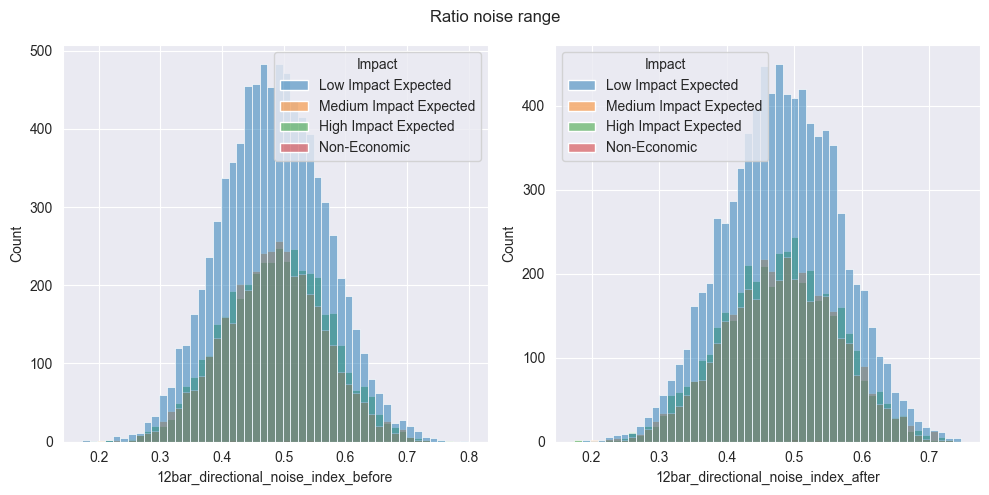

In [91]:
plot_before_and_after(df, x_before='12bar_directional_noise_index_before', x_after='12bar_directional_noise_index_after', hue='Impact', plot_type='hist', title='Ratio noise range')

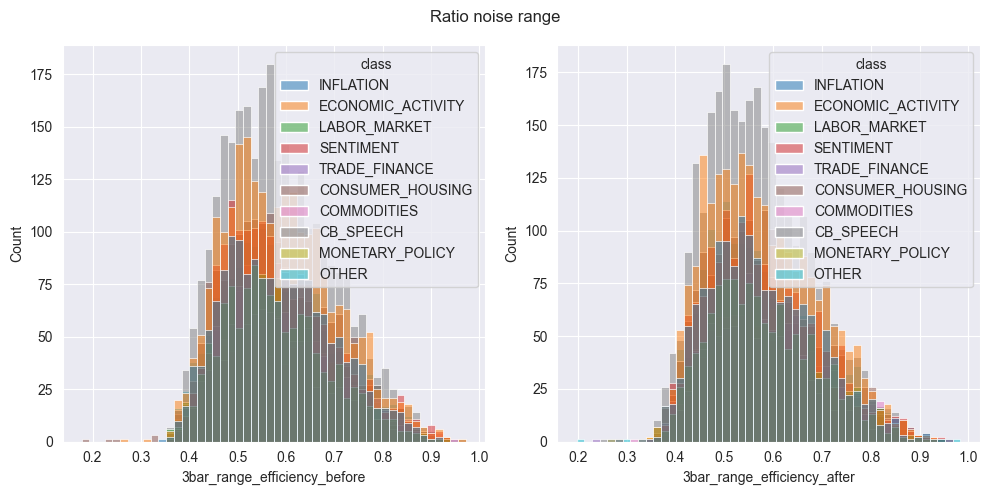

In [93]:
plot_before_and_after(df, x_before='3bar_range_efficiency_before', x_after='3bar_range_efficiency_after', hue='class', plot_type='hist', title='Ratio noise range')

## Исследование ренджа до и после новости (в разрезе степени влияния)

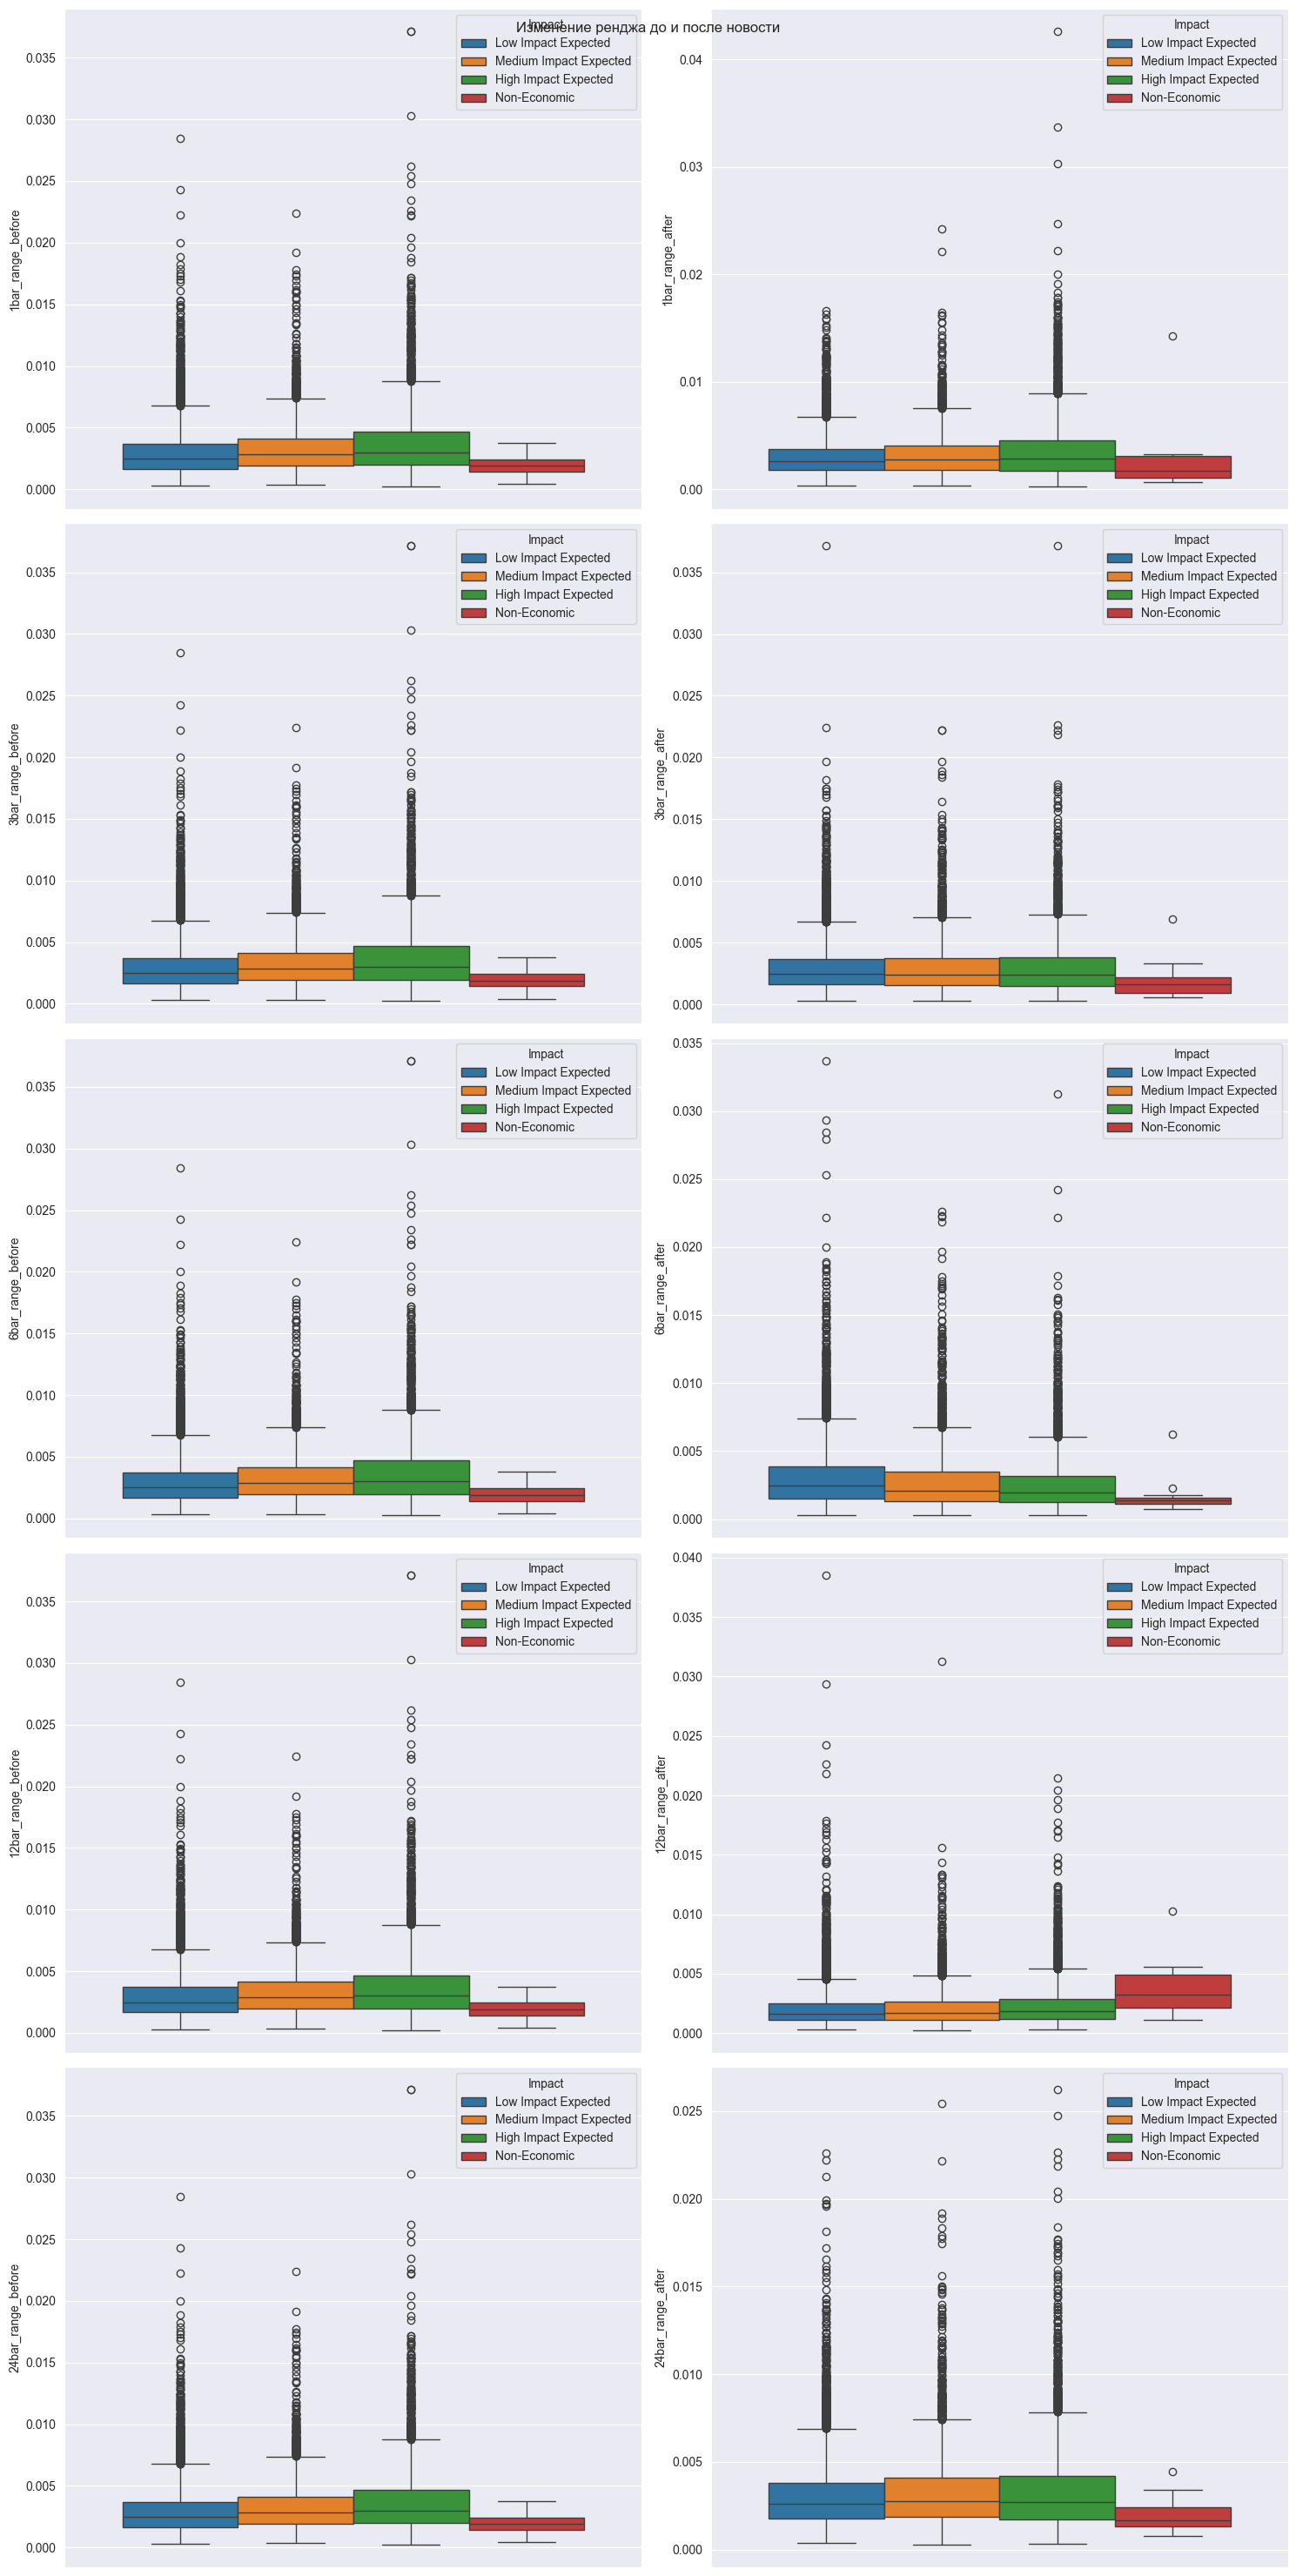

In [94]:
df_no_news = df[df['Impact'] != 'No news']
PLOT_TYPE = 'boxplot'
hue = 'Impact'
fig, ax = plt.subplots(5, 2, figsize=(15, 30))
fig.suptitle('Изменение ренджа до и после новости')
if PLOT_TYPE == 'hist':
    sns.histplot(data=df_no_news, x='1bar_range_before', hue=hue, bins=50, ax=ax[0, 0])
    sns.histplot(data=df_no_news, x='1bar_range_after', hue=hue, bins=50, ax=ax[0, 1])
    sns.histplot(data=df_no_news, x='3bar_range_before', hue=hue, bins=50, ax=ax[1, 0])
    sns.histplot(data=df_no_news, x='3bar_range_after', hue=hue, bins=50, ax=ax[1, 1])
    sns.histplot(data=df_no_news, x='6bar_range_before', hue=hue, bins=50, ax=ax[2, 0])
    sns.histplot(data=df_no_news, x='6bar_range_after', hue=hue, bins=50, ax=ax[2, 1])
    sns.histplot(data=df_no_news, x='12bar_range_before', hue=hue, bins=50, ax=ax[3, 0])
    sns.histplot(data=df_no_news, x='12bar_range_after', hue=hue, bins=50, ax=ax[3, 1])
    sns.histplot(data=df_no_news, x='24bar_range_before', hue=hue, bins=50, ax=ax[4, 0])
    sns.histplot(data=df_no_news, x='24bar_range_after', hue=hue, bins=50, ax=ax[4, 1])
elif PLOT_TYPE == 'boxplot':
    sns.boxplot(data=df_no_news, y='1bar_range_before', hue=hue, ax=ax[0, 0])
    sns.boxplot(data=df_no_news, y='1bar_range_after', hue=hue,  ax=ax[0, 1])
    sns.boxplot(data=df_no_news, y='3bar_range_before', hue=hue, ax=ax[1, 0])
    sns.boxplot(data=df_no_news, y='3bar_range_after', hue=hue,  ax=ax[1, 1])
    sns.boxplot(data=df_no_news, y='6bar_range_before', hue=hue, ax=ax[2, 0])
    sns.boxplot(data=df_no_news, y='6bar_range_after', hue=hue,  ax=ax[2, 1])
    sns.boxplot(data=df_no_news, y='12bar_range_before', hue=hue, ax=ax[3, 0])
    sns.boxplot(data=df_no_news, y='12bar_range_after', hue=hue, ax=ax[3, 1])
    sns.boxplot(data=df_no_news, y='24bar_range_before', hue=hue, ax=ax[4, 0])
    sns.boxplot(data=df_no_news, y='24bar_range_after', hue=hue, ax=ax[4, 1])
plt.tight_layout()
plt.show()

## Исследование тикового объема до и после новости (в разрезе степени влияния)

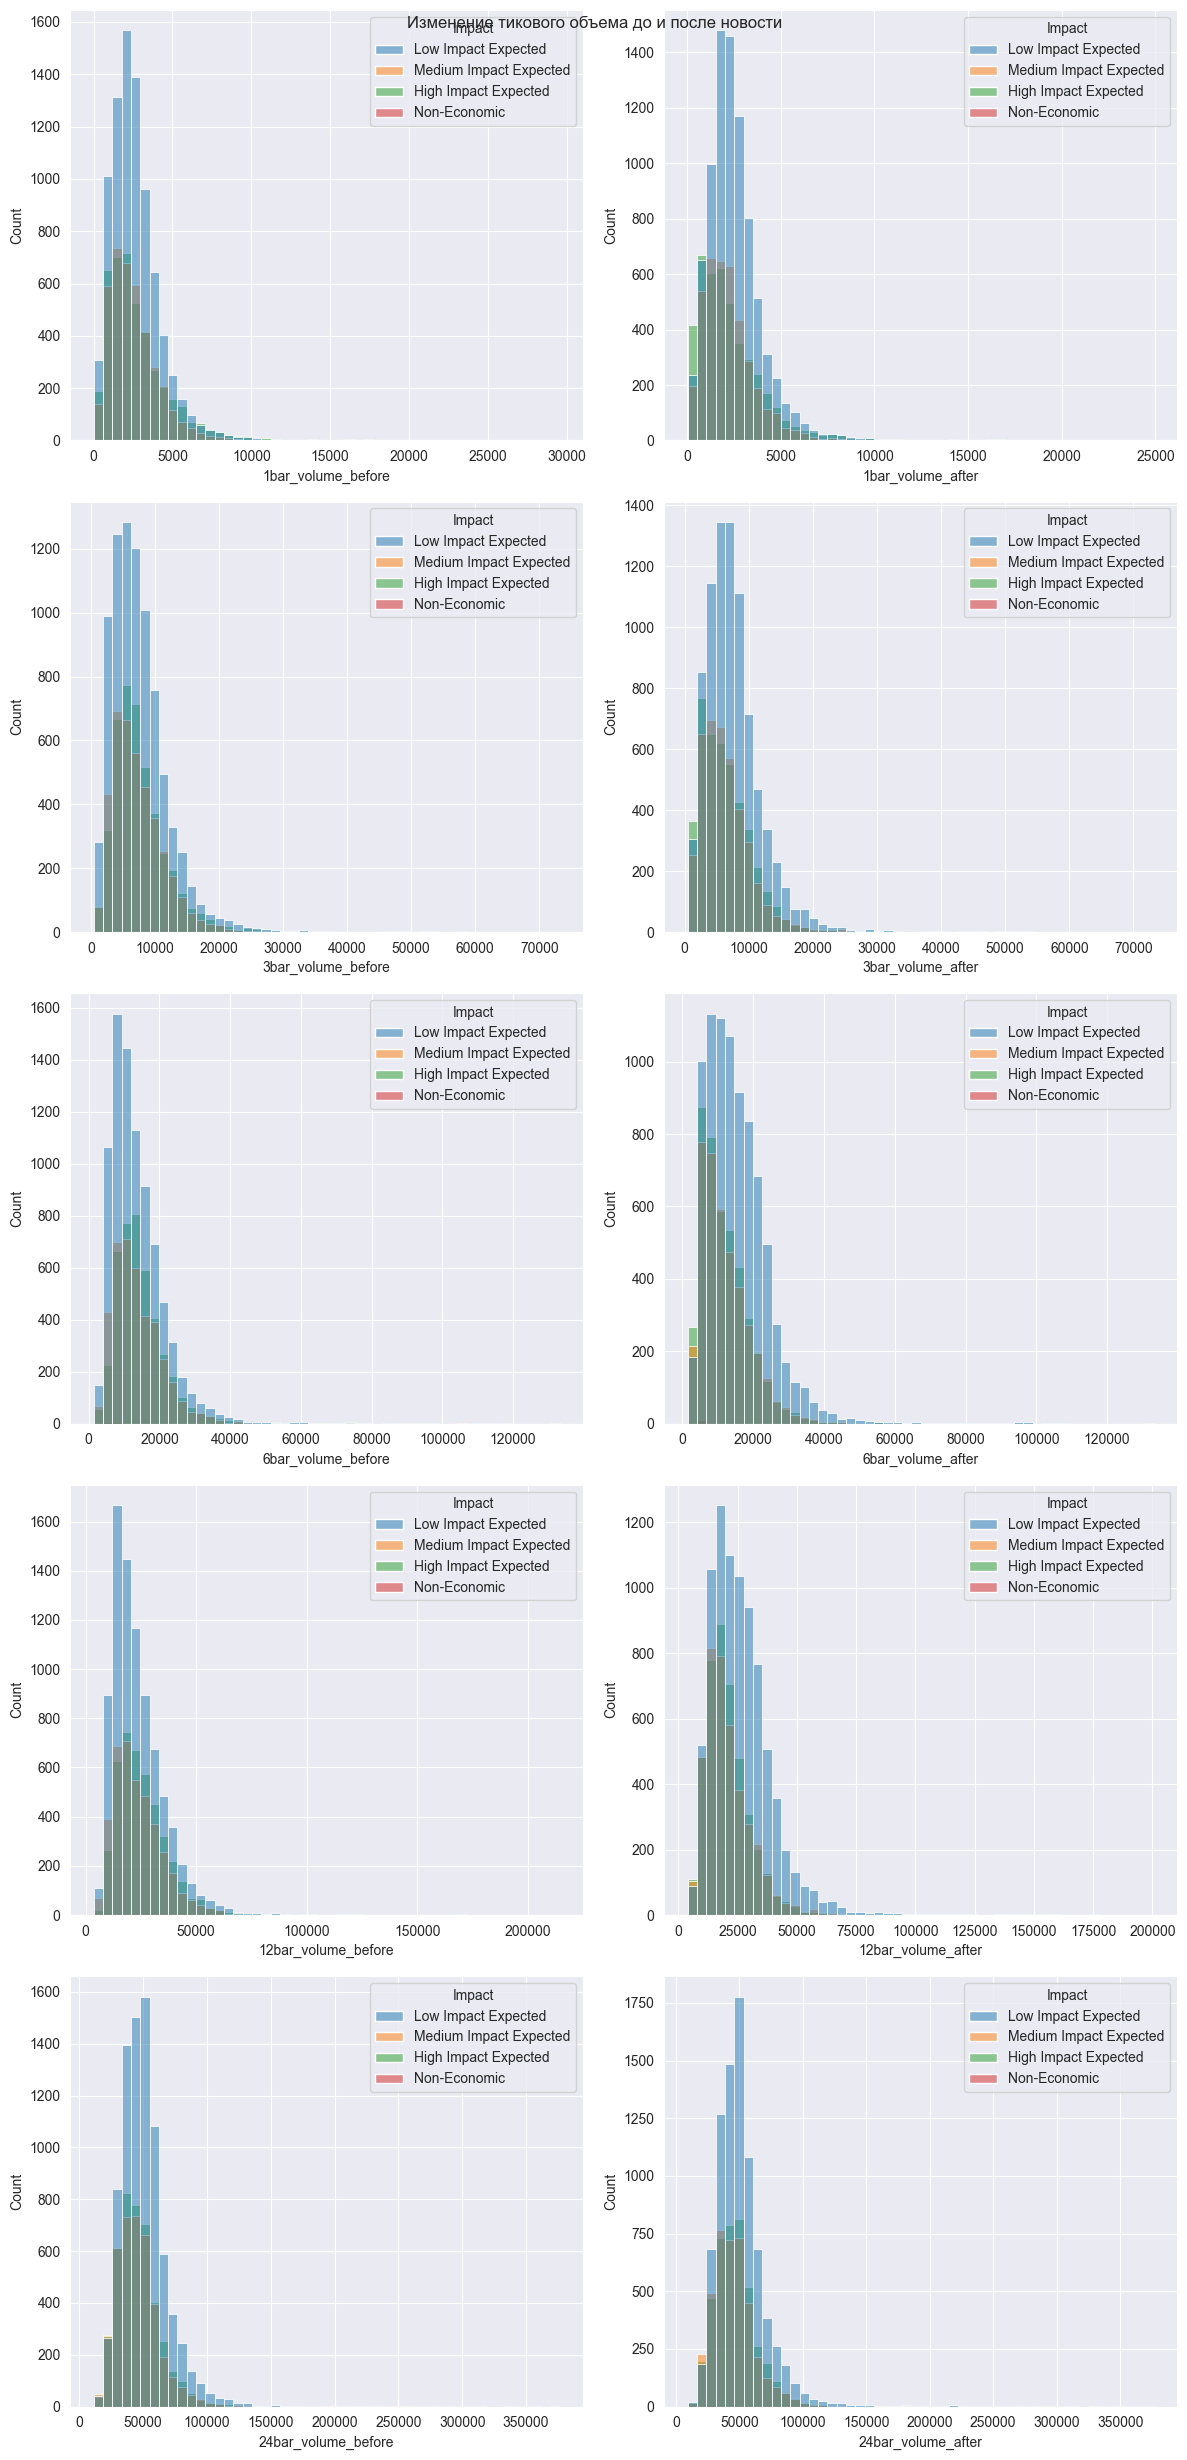

In [95]:
df_no_news = df[df['Impact'] != 'No news']
PLOT_TYPE = 'hist'
hue = 'Impact'
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
fig.suptitle('Изменение тикового объема до и после новости')
if PLOT_TYPE == 'hist':
    sns.histplot(data=df_no_news, x='1bar_volume_before', hue=hue, bins=50, ax=ax[0, 0])
    sns.histplot(data=df_no_news, x='1bar_volume_after', hue=hue, bins=50, ax=ax[0, 1])
    sns.histplot(data=df_no_news, x='3bar_volume_before', hue=hue, bins=50, ax=ax[1, 0])
    sns.histplot(data=df_no_news, x='3bar_volume_after', hue=hue, bins=50, ax=ax[1, 1])
    sns.histplot(data=df_no_news, x='6bar_volume_before', hue=hue, bins=50, ax=ax[2, 0])
    sns.histplot(data=df_no_news, x='6bar_volume_after', hue=hue, bins=50, ax=ax[2, 1])
    sns.histplot(data=df_no_news, x='12bar_volume_before', hue=hue, bins=50, ax=ax[3, 0])
    sns.histplot(data=df_no_news, x='12bar_volume_after', hue=hue, bins=50, ax=ax[3, 1])
    sns.histplot(data=df_no_news, x='24bar_volume_before', hue=hue, bins=50, ax=ax[4, 0])
    sns.histplot(data=df_no_news, x='24bar_volume_after', hue=hue, bins=50, ax=ax[4, 1])
elif PLOT_TYPE == 'boxplot':
    sns.boxplot(data=df_no_news, y='1bar_volume_before', hue=hue, ax=ax[0, 0])
    sns.boxplot(data=df_no_news, y='1bar_volume_after', hue=hue,  ax=ax[0, 1])
    sns.boxplot(data=df_no_news, y='3bar_volume_before', hue=hue, ax=ax[1, 0])
    sns.boxplot(data=df_no_news, y='3bar_volume_after', hue=hue,  ax=ax[1, 1])
    sns.boxplot(data=df_no_news, y='6bar_volume_before', hue=hue, ax=ax[2, 0])
    sns.boxplot(data=df_no_news, y='6bar_volume_after', hue=hue,  ax=ax[2, 1])
    sns.boxplot(data=df_no_news, y='12bar_volume_before', hue=hue, ax=ax[3, 0])
    sns.boxplot(data=df_no_news, y='12bar_volume_after', hue=hue, ax=ax[3, 1])
    sns.boxplot(data=df_no_news, y='24bar_volume_before', hue=hue, ax=ax[4, 0])
    sns.boxplot(data=df_no_news, y='24bar_volume_after', hue=hue, ax=ax[4, 1])
plt.tight_layout()
plt.show()

## Исследование экспоненты Херста до и после новости (в разрезе степени влияния)

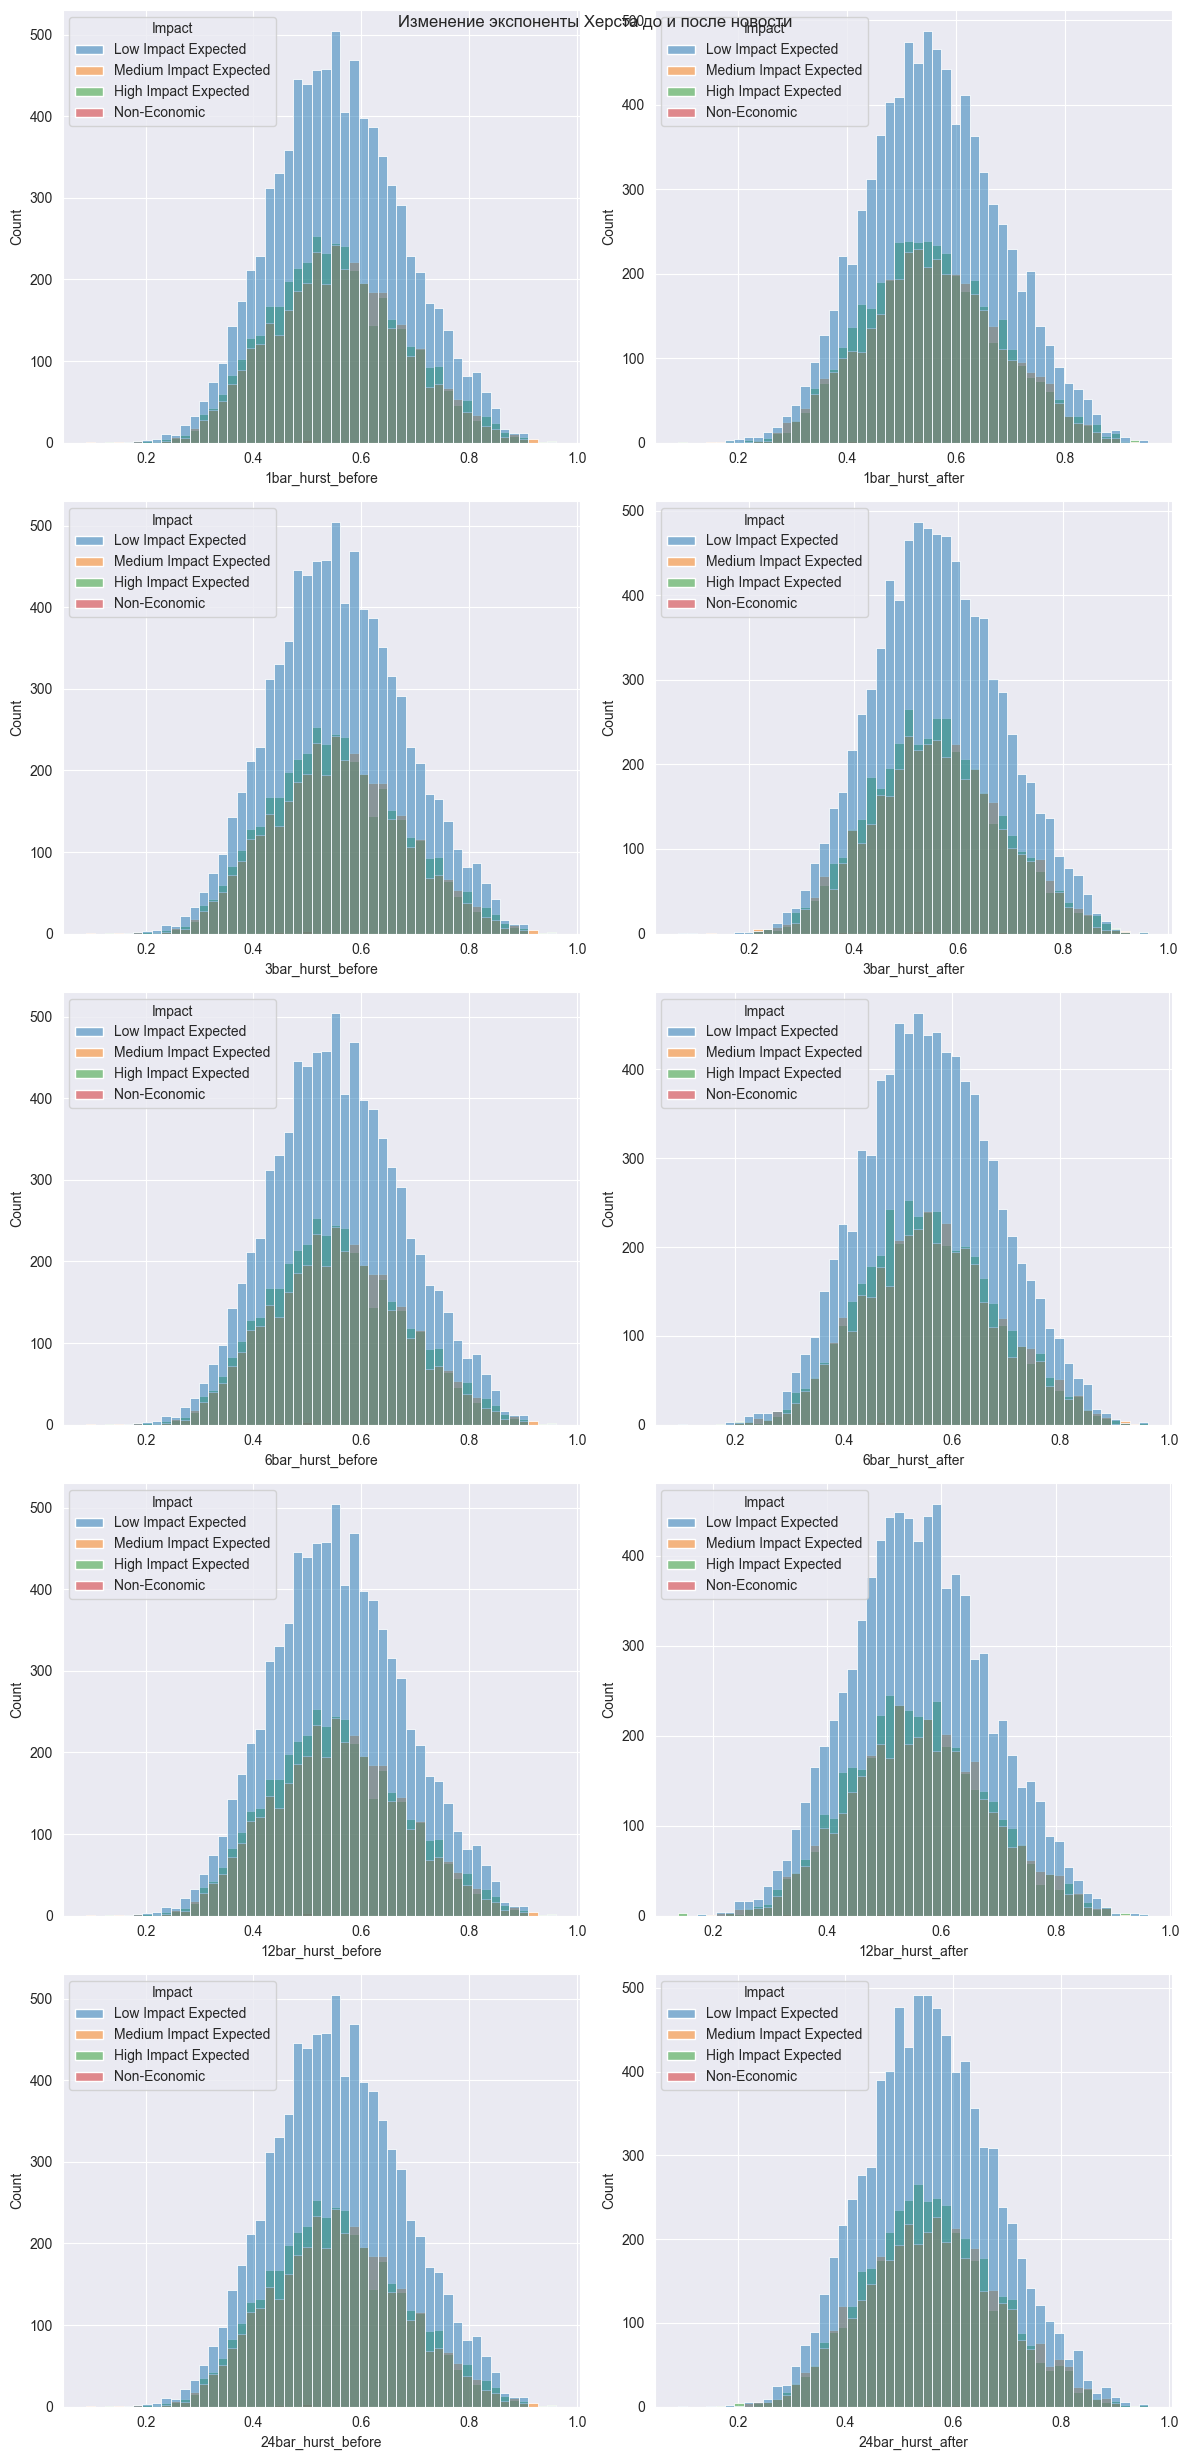

In [98]:
df_no_news = df[df['Impact'] != 'No news']
PLOT_TYPE = 'hist'
hue = 'Impact'
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
fig.suptitle('Изменение экспоненты Херста до и после новости')
if PLOT_TYPE == 'hist':
    sns.histplot(data=df_no_news, x='1bar_hurst_before', hue=hue, bins=50, ax=ax[0, 0])
    sns.histplot(data=df_no_news, x='1bar_hurst_after', hue=hue, bins=50, ax=ax[0, 1])
    sns.histplot(data=df_no_news, x='3bar_hurst_before', hue=hue, bins=50, ax=ax[1, 0])
    sns.histplot(data=df_no_news, x='3bar_hurst_after', hue=hue, bins=50, ax=ax[1, 1])
    sns.histplot(data=df_no_news, x='6bar_hurst_before', hue=hue, bins=50, ax=ax[2, 0])
    sns.histplot(data=df_no_news, x='6bar_hurst_after', hue=hue, bins=50, ax=ax[2, 1])
    sns.histplot(data=df_no_news, x='12bar_hurst_before', hue=hue, bins=50, ax=ax[3, 0])
    sns.histplot(data=df_no_news, x='12bar_hurst_after', hue=hue, bins=50, ax=ax[3, 1])
    sns.histplot(data=df_no_news, x='24bar_hurst_before', hue=hue, bins=50, ax=ax[4, 0])
    sns.histplot(data=df_no_news, x='24bar_hurst_after', hue=hue, bins=50, ax=ax[4, 1])
elif PLOT_TYPE == 'boxplot':
    sns.boxplot(data=df_no_news, y='1bar_hurst_before', hue=hue, ax=ax[0, 0])
    sns.boxplot(data=df_no_news, y='1bar_hurst_after', hue=hue,  ax=ax[0, 1])
    sns.boxplot(data=df_no_news, y='3bar_hurst_before', hue=hue, ax=ax[1, 0])
    sns.boxplot(data=df_no_news, y='3bar_hurst_after', hue=hue,  ax=ax[1, 1])
    sns.boxplot(data=df_no_news, y='6bar_hurst_before', hue=hue, ax=ax[2, 0])
    sns.boxplot(data=df_no_news, y='6bar_hurst_after', hue=hue,  ax=ax[2, 1])
    sns.boxplot(data=df_no_news, y='12bar_hurst_before', hue=hue, ax=ax[3, 0])
    sns.boxplot(data=df_no_news, y='12bar_hurst_after', hue=hue, ax=ax[3, 1])
    sns.boxplot(data=df_no_news, y='24bar_hurst_before', hue=hue, ax=ax[4, 0])
    sns.boxplot(data=df_no_news, y='24bar_hurst_after', hue=hue, ax=ax[4, 1])
plt.tight_layout()
plt.show()

<Axes: xlabel='hurst', ylabel='Count'>

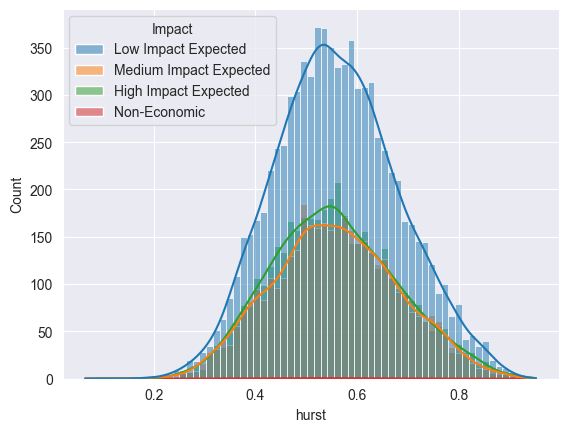

In [99]:
sns.histplot(df, x='hurst', hue='Impact', kde=True)

<Axes: xlabel='6bar_hurst_before', ylabel='6bar_hurst_after'>

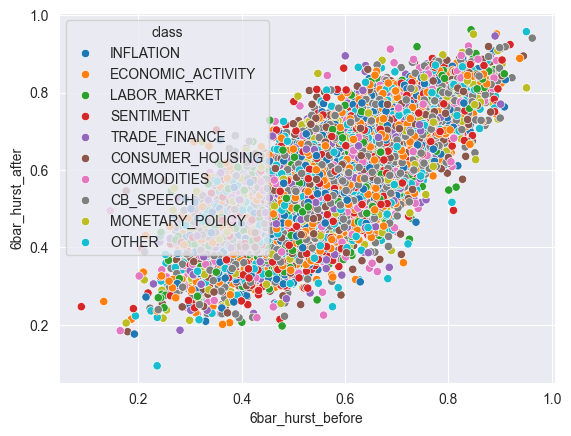

In [100]:
sns.scatterplot(df, x='6bar_hurst_before', y='6bar_hurst_after', hue='class')

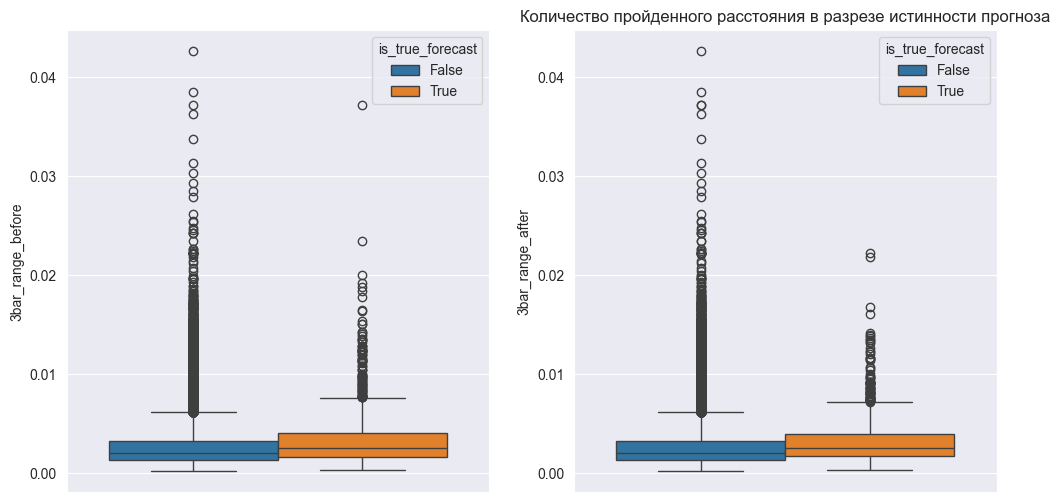

In [102]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

plt.title('Количество пройденного расстояния в разрезе истинности прогноза')
sns.boxplot(df, y='3bar_range_before', hue='is_true_forecast', ax=ax[0]);
sns.boxplot(df, y='3bar_range_after', hue='is_true_forecast', ax=ax[1]);

In [106]:
df.groupby('class').agg({'hurst': 'median', 
                            '3bar_hurst_before': 'median',
                            '3bar_hurst_after': 'median',
                            '12bar_hurst_before': 'median',
                            '12bar_hurst_after': 'median'})

,hurst,3bar_hurst_before,3bar_hurst_after,12bar_hurst_before,12bar_hurst_after
class,,,,,
CB_SPEECH,0.558012,0.556566,0.563189,0.556566,0.561760
COMMODITIES,0.552913,0.551758,0.555201,0.551758,0.555071
CONSUMER_HOUSING,0.559896,0.556653,0.557845,0.556653,0.557327
ECONOMIC_ACTIVITY,0.550102,0.552366,0.549377,0.552366,0.557429
INFLATION,0.544571,0.546474,0.548760,0.546474,0.553669
LABOR_MARKET,0.556656,0.552189,0.557075,0.552189,0.557372
MONETARY_POLICY,0.541918,0.543195,0.550016,0.543195,0.553343
OTHER,0.554230,0.552143,0.551209,0.552143,0.550232
SENTIMENT,0.553426,0.552849,0.558571,0.552849,0.559877


In [109]:
df.groupby('Event')['3bar_range_before'].agg([
    ('mean_value', 'mean'),
    ('count_value', 'count')
]).sort_values('count_value', ascending=False)

,mean_value,count_value
Event,,
Crude Oil Inventories,0.004256,498
Natural Gas Storage,0.004963,470
Unemployment Claims,0.003029,256
PPI m/m,0.002982,217
10-y Bond Auction,0.002978,211
...,...,...
EBA Bank Stress Test Results,0.003250,1
EU Membership Court Ruling,0.002420,1
EU Membership Vote,0.005120,1


<Axes: xlabel='readable_range', ylabel='Count'>

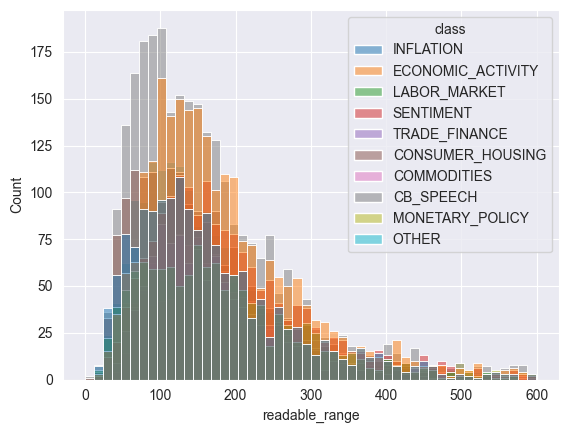

In [110]:
sns.histplot(data=df.query('readable_range < 600'), x='readable_range', bins=50, hue='class')

<Axes: xlabel='readable_range', ylabel='Count'>

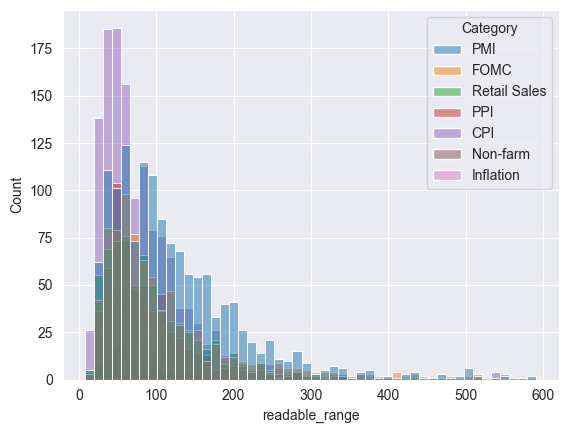

In [ ]:
sns.histplot(data=df.query('readable_range < 600'), x='readable_range', bins=50, hue='Category')